# Six Months After the Fire

### Planet Tanager Open Data Competition

**Santa Monica Mountains, Los Angeles County — January to July 2025**

In January 2025 the Palisades Fire burned 96 km² of the Santa Monica Mountains. **No
authored burn-severity product exists for it, or for the Franklin and Kenneth fires beside
it.** All three were state-responsibility incidents, so the federal mapping programmes have
no coverage: MTBS lags ~18 months, and the 2025 USFS BAER mosaic returns zero valid pixels
over this ground. Four candidate products were checked and rejected (section 5). Anyone
planning debris-flow response or vegetation recovery above Malibu and Pacific Palisades is
working without a severity map.

Two Tanager-1 hyperspectral scenes overlap this area: **23 January 2025**, sixteen days
after ignition, and **26 July 2025**, six months into recovery. Both carry **426 spectral
bands** from 376 to 2499 nm. This notebook builds the missing map from them.

This notebook asks three questions, in an order where each one earns the next:

> **Q1 — Can a spectrometer weigh what fire left behind as a *material*?**
> Every operational burn-severity product is a two-band ratio calibrated against field
> severity. A 426-band cube can instead ask *how much charred material is in this pixel*.

> **Q2 — How far can you trust a fraction measured from orbit?**
> Unmixing is easy to do and easy to fool. NASA/JPL flew AVIRIS-3 over these fires **the
> same day**, which turns the check into char fraction against char fraction.

> **Q3 — Does what burned determine what comes back?**
> The two fires burned near-opposite vegetation, which invalidated our own first answer.
> Fixing it required a per-vegetation-type control and a severity control.

The method throughout: the two dates were acquired at **34° and 73° sun elevation**, which
sinks any attempt to difference a burn index across them. So we unmix each date separately
onto a shared endmember library and compare *fractions*. A photometric **shade** endmember absorbs the illumination
difference — which is what makes the comparison valid at all, and is why there is no
index-based version of this notebook.

> **How this project actually went.** The original plan was a conventional pre-fire/post-fire
> dNBR. That plan did not survive contact with the data, and neither did four later claims —
> including one of our own headline results. Part V lists everything we tested and
> rejected, because each rejection determined what the final method had to be.

## 0. Setup

Everything below reads artifacts produced by the `scripts/` pipeline:

| script | produces |
|---|---|
| `fetch_metadata.py` | STAC item JSON, asset inventory |
| `validate_fire_signal.py` | fire perimeters, footprint intersection |
| `invariant_check.py` / `crossdate_gain.py` | cross-date radiometric calibration |
| `endmembers.py` | endmember library + separability |
| `unmix.py` | per-date fraction maps (FCLS) |
| `analyze.py` | recovery statistics |
| `sentinel2.py` / `validate.py` | pre-burn baseline + independent dNBR check |
| `aviris3.py` | same-day AVIRIS-3 char-vs-char validation |
| `vegtype.py` | LANDFIRE pre-fire vegetation type + CAL FIRE burn history |
| `recovery_by_type.py` | stratified recovery, per-type and per-severity controls |

Those artifacts (`data/*.npz`, `data/*.tif`) are not in the repository — they are rebuilt by
running the scripts above, in that order. The outputs saved in this notebook are the record
of the run they came from.

In [1]:
import json, sys
sys.path.insert(0, "scripts")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

FRAC = np.load("data/fractions.npz")
S2   = np.load("data/sentinel2.npz", allow_pickle=True)
EM   = np.load("data/endmembers.npz", allow_pickle=True)
GAIN = np.load("data/crossdate_gain.npz")
VEG  = np.load("data/vegtype.npz")
RBT  = json.load(open("data/recovery_by_type.json"))

NAMES = [str(n) for n in FRAC["names"]]
iGV, iNS, iCH, iSH = (NAMES.index(k) for k in ("GV", "NPV_SOIL", "CHAR", "SHADE"))
print("endmembers:", NAMES)
print("overlap grid:", FRAC["frac_jan23"].shape[1:], "@ 30 m, EPSG:32611")

endmembers: ['GV', 'NPV_SOIL', 'CHAR', 'SHADE']
overlap grid: (713, 743) @ 30 m, EPSG:32611


# Part I — What actually burned, and can these two dates be compared?

Two things had to be established before any question could be asked: **what burned and
when**, which only the authoritative perimeter record can settle, and **whether a 34°-sun
scene can be compared to a 73°-sun scene at all**.
The second one is the load-bearing result of the whole project.

## 1. The plot twist: nothing burned between the two scenes

The project began by assuming January was "before" and July was "after". Before building
anything on that, we checked it against the NIFC/WFIGS interagency fire perimeter archive.
The imagery itself cannot settle the question: January is wet-season green and July is
dry-season brown, so *everything* looks darker in July.

**Every fire in the area predates the January scene.**

In [2]:
from shapely.geometry import shape, Polygon
from shapely.ops import transform as shp_transform
from pyproj import Transformer
import datetime

UTM = Transformer.from_crs(4326, 32611, always_xy=True).transform
km2 = lambda g: shp_transform(UTM, g).area / 1e6

JUL26 = Polygon([(-118.7910628466147, 34.21932506980487), (-118.84336011674677, 34.0512100596783),
                 (-118.61020764125392, 33.99952075931865), (-118.57294146689644, 34.17803482712942)])
JAN23 = Polygon([(-118.74674636594759, 34.19042451838735), (-118.81000229560739, 33.95259148244884),
                 (-118.56582754732204, 33.90531288319584), (-118.5024818852516, 34.14556791007762)])
overlap = JUL26.intersection(JAN23)

perims = json.load(open("data/fire_perimeters_2024_2025.geojson"))
print(f"{'fire':12s} {'discovered':12s} {'km2':>7s} {'in overlap km2':>15s}")
total = 0
for f in sorted(perims["features"], key=lambda f: -(f["properties"].get("attr_IncidentSize") or 0)):
    g = shape(f["geometry"]).buffer(0)
    if km2(g) < 0.05:
        continue
    ts = f["properties"]["attr_FireDiscoveryDateTime"]
    disc = datetime.datetime.fromtimestamp(ts/1000, datetime.UTC).date()
    inov = km2(g.intersection(overlap))
    total += inov
    print(f"{f['properties']['poly_IncidentName'][:12]:12s} {str(disc):12s} {km2(g):7.1f} {inov:15.1f}")

print(f"\nTanager overlap: {km2(overlap):.1f} km2")
print(f"burned area inside it: {total:.1f} km2  ({100*total/km2(overlap):.1f}%)")
print("\nBoth Tanager scenes are POST-fire. The pair is a recovery series, not a before/after.")

fire         discovered       km2  in overlap km2
PALISADES    2025-01-07      96.1            29.8
Franklin     2024-12-10      17.0            17.0
KENNETH      2025-01-09       4.0             2.8
BROAD        2024-11-06       0.2             0.2

Tanager overlap: 289.5 km2
burned area inside it: 49.7 km2  (17.2%)

Both Tanager scenes are POST-fire. The pair is a recovery series, not a before/after.


Both acquisitions sit *after* every fire. That reframes the project entirely — and for the
better. One before/after contrast becomes a **recovery trajectory across three scars of
different ages**, all inside a single same-sensor overlap:

| fire | ignited | age at Jan 23 scene | age at Jul 26 scene |
|---|---|---:|---:|
| Franklin | 10 Dec 2024 | 44 days | 228 days |
| Palisades | 7 Jan 2025 | 16 days | 200 days |
| Kenneth | 9 Jan 2025 | 14 days | 198 days |

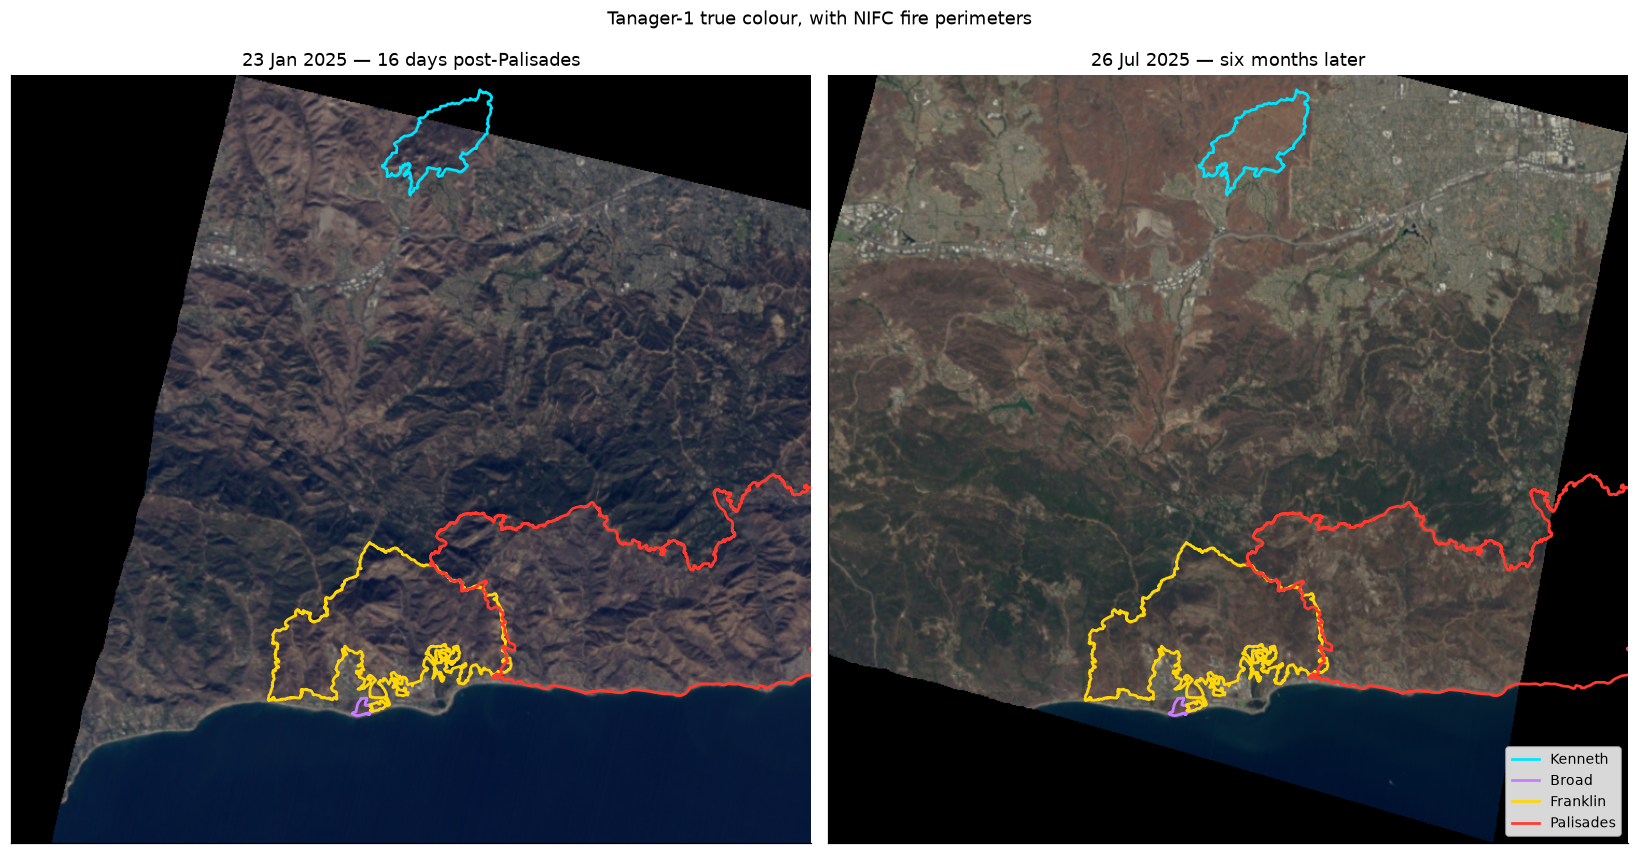

In [3]:
import rasterio
from rasterio.windows import from_bounds

BOX = [332760, 3763260, 355050, 3784650]   # overlap, EPSG:32611
COLORS_FIRE = {"PALISADES": "#ff3b30", "Franklin": "#ffd60a", "KENNETH": "#00e5ff", "BROAD": "#c77dff"}
QL = {"jan23": ("20250123_185518_92_4001", "23 Jan 2025 — 16 days post-Palisades"),
      "jul26": ("20250726_192422_87_4001", "26 Jul 2025 — six months later")}

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
for ax, (item_id, title) in zip(axes, QL.values()):
    with rasterio.open(f"data/quicklook/{item_id}_visual.tif") as src:
        rgb = src.read([1, 2, 3], window=from_bounds(*BOX, src.transform),
                       boundless=True, fill_value=0)
    ax.imshow(np.transpose(rgb, (1, 2, 0)), extent=[BOX[0], BOX[2], BOX[1], BOX[3]])
    seen = set()
    for f in perims["features"]:
        n = f["properties"]["poly_IncidentName"]
        if n not in COLORS_FIRE:
            continue
        g = shp_transform(UTM, shape(f["geometry"]).buffer(0))
        for part in (g.geoms if g.geom_type == "MultiPolygon" else [g]):
            ax.plot(*part.exterior.xy, color=COLORS_FIRE[n], lw=1.8,
                    label=n.title() if n not in seen else None)
            seen.add(n)
    ax.set(title=title, xticks=[], yticks=[], xlim=BOX[0:3:2], ylim=BOX[1::2])
    ax.grid(False)
axes[1].legend(loc="lower right", framealpha=0.85, fontsize=9)
fig.suptitle("Tanager-1 true colour, with NIFC fire perimeters", y=0.99)
plt.tight_layout()

## 2. Can these two dates even be compared?

Before differencing anything, a hard problem has to be confronted. The two acquisitions
are very different:

| | 23 Jan | 26 Jul |
|---|---|---|
| sun elevation | **34.1°** | **73.0°** |
| quality flag | `test` | `standard` |
| collection mode | standard sensitivity | maximum sensitivity |

A 39° difference in solar elevation, over terrain this steep, means a naive band difference
would largely measure *topographic shadow* and only incidentally the surface. And one scene
is flagged `test`.

So we measured it. Over **pseudo-invariant features** — surfaces that genuinely cannot
change between January and July — we fit `R_jul = gain · R_jan + offset` per band. Crucially,
the fit **excludes every fire perimeter**, so the scars we want to measure cannot
contaminate the calibration.

median gain   1.050   (p5 0.951, p95 1.090)
median offset +0.0002
median R²     0.862
usable bands after cross-date QA: 355 of 426


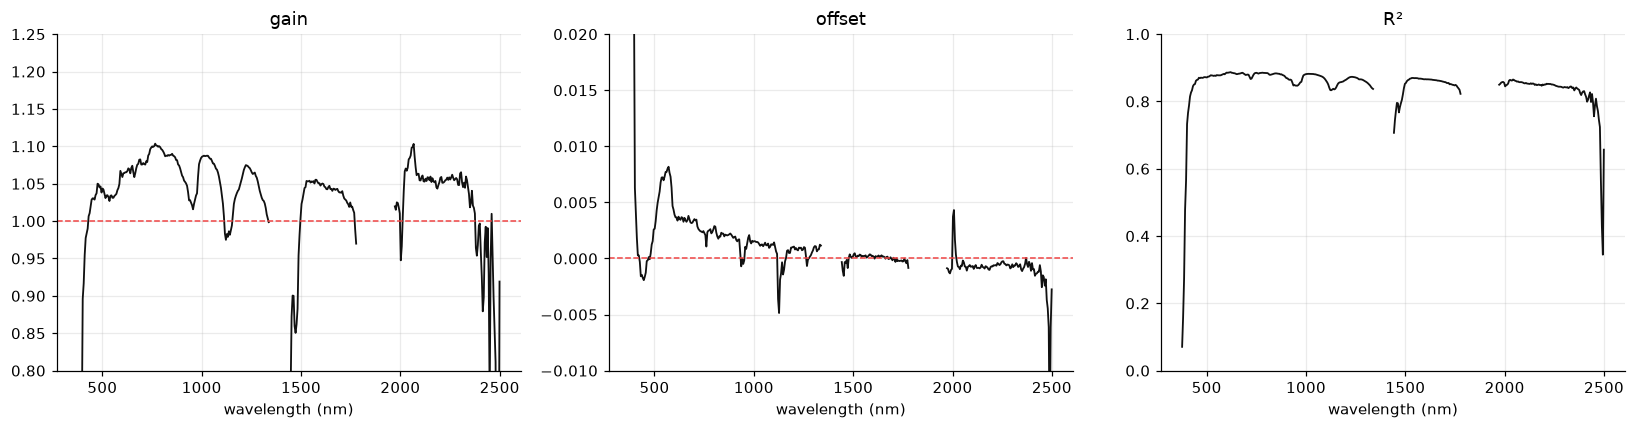

In [4]:
wl, gain, offset, r2, good = (GAIN[k] for k in ("wavelengths", "gain", "offset", "r2", "good"))
show = lambda a: np.where(good, a, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, arr, name, ref in [(axes[0], gain, "gain", 1.0),
                           (axes[1], offset, "offset", 0.0),
                           (axes[2], r2, "R²", None)]:
    ax.plot(wl, show(arr), color="#111", lw=1.2)
    if ref is not None:
        ax.axhline(ref, color="#ef4444", ls="--", lw=1)
    ax.set(xlabel="wavelength (nm)", title=name)
axes[0].set_ylim(0.8, 1.25); axes[1].set_ylim(-0.01, 0.02); axes[2].set_ylim(0, 1)
plt.tight_layout()

usable = np.load("data/usable_bands.npy")
print(f"median gain   {np.nanmedian(gain[usable]):.3f}   "
      f"(p5 {np.nanpercentile(gain[usable],5):.3f}, p95 {np.nanpercentile(gain[usable],95):.3f})")
print(f"median offset {np.nanmedian(offset[usable]):+.4f}")
print(f"median R²     {np.nanmedian(r2[usable]):.3f}")
print(f"usable bands after cross-date QA: {usable.sum()} of {len(usable)}")

**This is the result the whole project rests on.** July is brighter than January by a
**spectrally flat ~5% gain**, with essentially **zero additive offset**, and R² ≈ 0.86.

Two things follow:

1. The `test` quality flag does **not** mean spectral distortion — the gain curve is smooth,
   with no band-to-band jumps. The dates are spectrally consistent.
2. A flat multiplicative gain is a **brightness** term. And a brightness term is exactly
   what a photometric **shade endmember** absorbs in a linear unmixing.

That second point is the justification for the entire method. We do not need to defeat the
sun-angle difference with topographic modelling — we need only to give it somewhere to go.
Unmixing gives it the shade fraction.

# Part II — Q1. Can we measure fire residue as a material?

An index tells you *that* something changed. The claim tested here is stronger: that the
426 bands identify **charred material** as a substance, with a meaningful zero. The test is
whether the char endmember stays silent where there was no fire.

Two things need separating before that test means anything. **Inference is blind**: FCLS
runs per pixel over 355 reflectance values, with no coordinates, no neighbourhood and no
mask, so nothing in the unmixing can enforce a spatial boundary. **Library construction was
not**: the char endmember is the median of dark, low-NDVI pixels *inside* the NIFC
perimeters, and the two vegetation endmembers are drawn from outside them. An earlier
version of this work claimed the unmixing "was never told where the fires were", which was
false. `FINDINGS.md` measures how much that dependency is worth, and section 6 returns to
it.

## 3. Building the endmember library — and two failures worth keeping

**Failure 1.** Blind Vertex Component Analysis over the whole overlap returned *deep ocean*
and *deep topographic shadow* as simplex vertices. The extremes of a coastal mountain scene
have nothing to do with fire.

**Failure 2.** Region-constrained VCA with hand-specified absorption features also failed —
subtly. The assumed continuum shoulders were wrong: the true SWIR2 continuum in these
spectra peaks near 2200 nm, so every "absorption depth" measured against fixed 1990/2450 nm
shoulders came out **negative**, and no candidate ever matched soil or dry vegetation.

The fix was to stop assuming a library and **measure which materials are separable**, using
spectral angle. Being brightness-invariant, it isolates material differences from
illumination differences.

In [5]:
lib, names_em, wl_em = EM["library"], [str(n) for n in EM["names"]], EM["wavelengths"]
ang = lambda a, b: np.degrees(np.arccos(np.clip(a @ b / (np.linalg.norm(a)*np.linalg.norm(b)), -1, 1)))

mat = names_em[:-1]   # exclude SHADE (zero vector)
print("pairwise spectral angle (degrees) — the library that was kept")
print(" " * 11 + "".join(f"{n:>10s}" for n in mat))
for i, n in enumerate(mat):
    print(f"{n:>10s} " + "".join(f"{ang(lib[i], lib[j]):10.1f}" for j in range(len(mat))))
print(f"\ncondition number of design matrix: {np.linalg.cond(lib[:-1].T):.1f}")

# The two candidates that were rejected, over the same 355 bands.
CM = np.load("data/class_medians.npz")
print("\nrejected candidates — separability against what is already in the library")
for a_name, b_name, label in [("CHAR", "BURNBRT", "char vs bright burned substrate"),
                              ("BURNBRT", "ASHcand", "bright burn vs white-ash candidate")]:
    print(f"  {label:36s}{ang(CM[a_name+'.jan23'], CM[b_name+'.jan23']):5.1f} deg")

pairwise spectral angle (degrees) — the library that was kept
                   GV  NPV_SOIL      CHAR
        GV        0.0      25.3      34.7
  NPV_SOIL       25.3       0.0      11.2
      CHAR       34.7      11.2       0.0

condition number of design matrix: 25.8

rejected candidates — separability against what is already in the library
  char vs bright burned substrate       5.4 deg
  bright burn vs white-ash candidate    2.8 deg


The measurement returned a **negative result that changed the model**: candidate "white ash"
sits **2.8°** from bright burned substrate, and bright burned substrate sits **5.4°** from
char. Dark and bright burned areas share a spectral *shape* and differ only in *brightness* —
which the shade endmember already handles.

So there is **no separable white-ash endmember** here: sixteen days after ignition, at 30 m,
following a major Santa Ana wind event, no distinct ash signal survives. Forcing ASH into
the library would only make the system ill-conditioned for no gain.

**Final library: GV, NPV/soil, char, shade** — four members, chosen by the data.

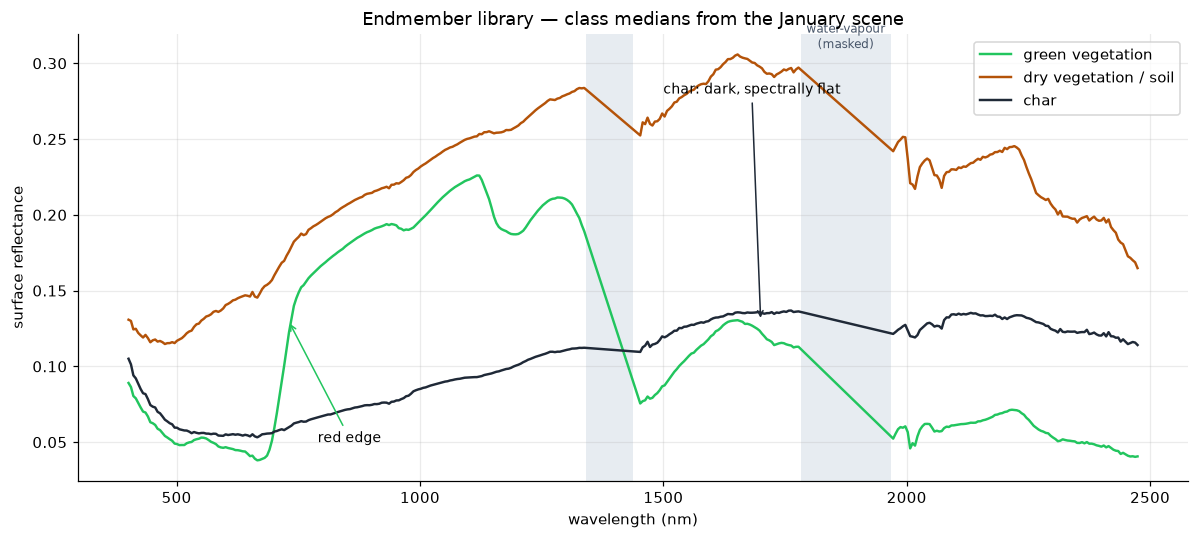

In [6]:
COLORS_EM = {"GV": "#22c55e", "NPV_SOIL": "#b45309", "CHAR": "#1f2937"}
LABELS_EM = {"GV": "green vegetation", "NPV_SOIL": "dry vegetation / soil", "CHAR": "char"}

fig, ax = plt.subplots(figsize=(11, 5))
for row, name in zip(lib, names_em):
    if name == "SHADE":
        continue
    ax.plot(wl_em, row, lw=1.6, color=COLORS_EM[name], label=LABELS_EM[name])
for lo, hi, lab in [(1342, 1438, None), (1783, 1967, "water-vapour\n(masked)")]:
    ax.axvspan(lo, hi, color="#cbd5e1", alpha=0.45, lw=0)
    if lab:
        ax.text((lo+hi)/2, 0.31, lab, ha="center", fontsize=8, color="#475569")
ax.annotate("red edge", xy=(730, 0.13), xytext=(790, 0.05), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#22c55e"))
ax.annotate("char: dark, spectrally flat", xy=(1700, 0.13), xytext=(1500, 0.28), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#1f2937"))
ax.set(xlabel="wavelength (nm)", ylabel="surface reflectance",
       title="Endmember library — class medians from the January scene")
ax.legend()
plt.tight_layout()

## 4. Unmixing both dates

Fully-constrained least squares (Heinz & Chang 2001) per pixel, over 355 cross-date-QA'd
bands, solving for fractions that are non-negative and sum to one. Both dates use the
**same** library, which is what makes the two sets of fractions differenceable.

The whole 713 × 743 overlap unmixes in about 15 seconds per date.

In [7]:
# Shade-normalized fractions: f / (1 - f_shade) — the cross-date comparable quantity.
def normalized(date):
    f = FRAC[f"frac_{date}"]
    return f / np.clip(1.0 - f[iSH], 1e-3, None)

norm = {d: normalized(d) for d in ("jan23", "jul26")}
valid = {d: np.isfinite(FRAC[f"rmse_{d}"]) & (FRAC[f"frac_{d}"][iSH] < 0.9)
         for d in ("jan23", "jul26")}
both = valid["jan23"] & valid["jul26"]

print(f"{'date':8s} {'GV':>8s} {'NPV/soil':>10s} {'char':>8s} {'shade':>8s} {'RMSE':>8s}")
for d in ("jan23", "jul26"):
    f = FRAC[f"frac_{d}"]
    print(f"{d:8s} {np.nanmean(f[iGV]):8.3f} {np.nanmean(f[iNS]):10.3f} "
          f"{np.nanmean(f[iCH]):8.3f} {np.nanmean(f[iSH]):8.3f} "
          f"{np.nanmedian(FRAC[f'rmse_{d}']):8.4f}")
print("\nShade tracks the sun elevation (0.274 at 34°, 0.072 at 73°) — exactly as intended.")
print("That is the illumination difference landing in shade instead of in the materials.")

date           GV   NPV/soil     char    shade     RMSE
jan23       0.261      0.381    0.085    0.274   0.0167
jul26       0.210      0.715    0.005    0.072   0.0383

Shade tracks the sun elevation (0.274 at 34°, 0.072 at 73°) — exactly as intended.
That is the illumination difference landing in shade instead of in the materials.


Text(0.5, 0.95, 'Shade-normalized endmember fractions')

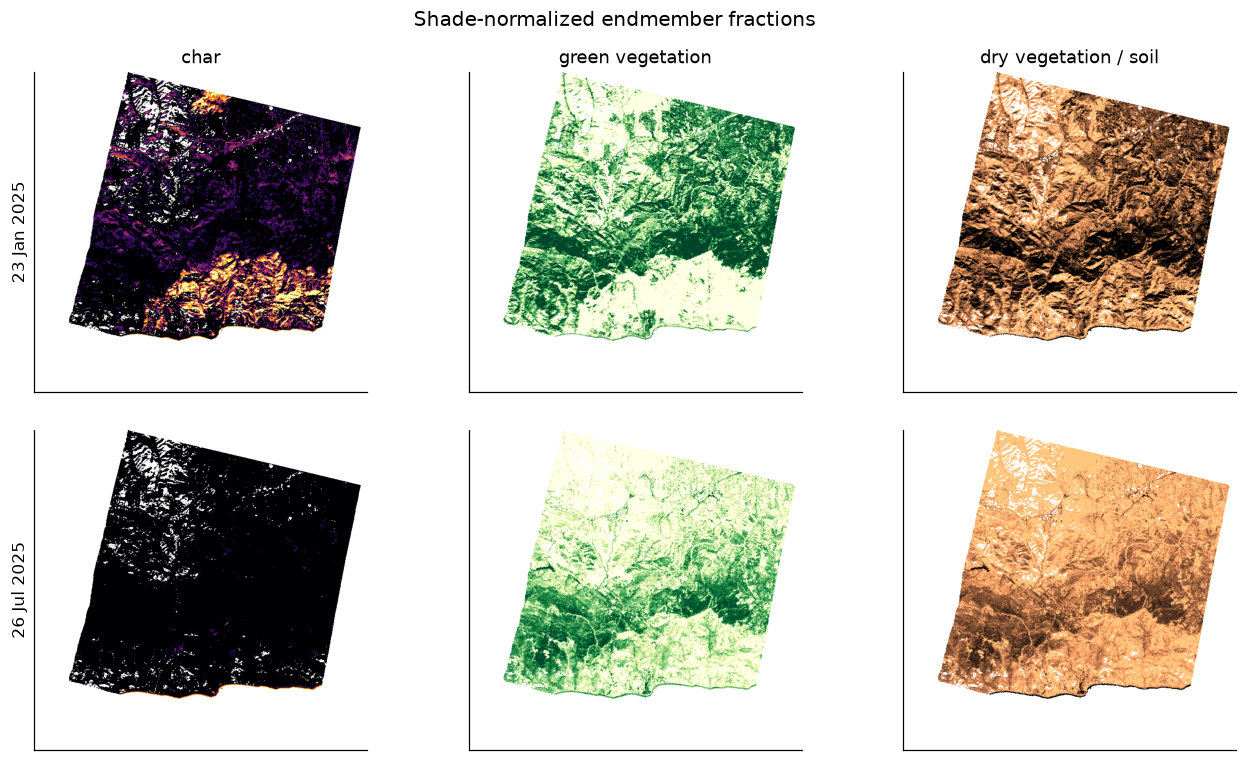

In [8]:
fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.12, wspace=0.06)
for r, (d, lab) in enumerate([("jan23", "23 Jan 2025"), ("jul26", "26 Jul 2025")]):
    for c, (idx, name, cmap, vmax) in enumerate(
            [(iCH, "char", "inferno", 0.8), (iGV, "green vegetation", "YlGn", 0.8),
             (iNS, "dry vegetation / soil", "copper", 1.0)]):
        ax = fig.add_subplot(gs[r, c])
        ax.imshow(np.where(both, norm[d][idx], np.nan), cmap=cmap, vmin=0, vmax=vmax)
        ax.set(xticks=[], yticks=[]); ax.grid(False)
        if r == 0:
            ax.set_title(name)
        if c == 0:
            ax.set_ylabel(lab, fontsize=11)
fig.suptitle("Shade-normalized endmember fractions", y=0.95, fontsize=13)

In [9]:
from analyze import per_fire_masks
masks, any_fire = per_fire_masks(*both.shape, FRAC["origin"])
control = both & ~any_fire
print("fires:", list(masks), "| control px:", int(control.sum()))

fires: ['PALISADES', 'Franklin', 'KENNETH'] | control px: 221399


# Part III — Q2. How far can we trust a fraction from orbit?

Fractions from a poorly conditioned library look entirely plausible and mean nothing. Two
independent checks follow: Sentinel-2 dNBR (a different sensor, different processing chain,
different algorithm), and then the strongest available — **AVIRIS-3, airborne, the same
day, 1.4 hours later**, which puts char fraction up against char fraction — no severity
proxy in between.

## 5. The missing "before", and an independent check

Tanager has no pre-fire scene here — its earliest acquisition is already 16 days
post-ignition. **Sentinel-2 supplies the missing before**, and does double duty as
independent validation.

Scene selection turned out to matter more than expected: the Sentinel-2 scenes *closest in
date* to the Tanager acquisitions are partial swaths covering only the western third of the
AOI (74% nodata). A STAC bbox intersection is **not** coverage. Scenes here are filtered on
footprint containment plus `s2:nodata_pixel_percentage < 5`.

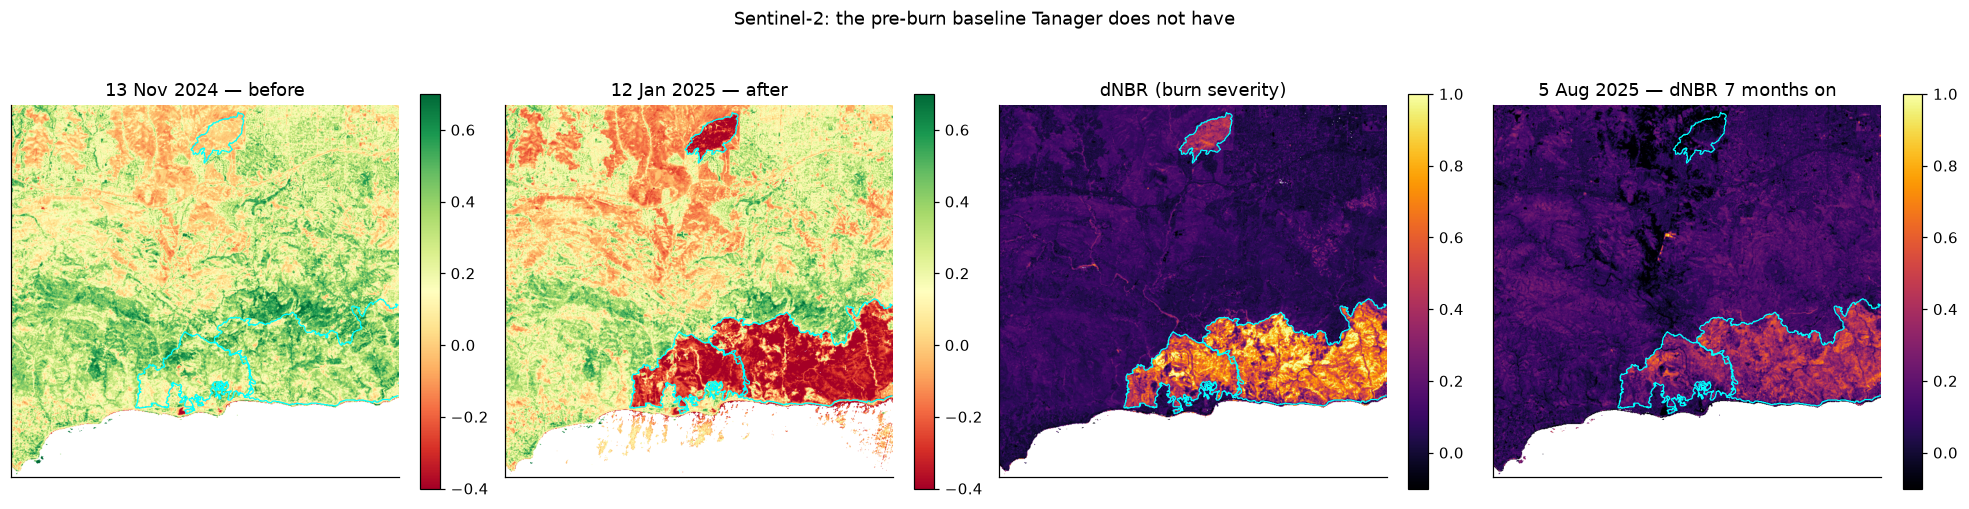

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
panels = [("nbr_pre", "13 Nov 2024 — before", "RdYlGn", -0.4, 0.7),
          ("nbr_post", "12 Jan 2025 — after", "RdYlGn", -0.4, 0.7),
          ("dnbr_post", "dNBR (burn severity)", "inferno", -0.1, 1.0),
          ("dnbr_late", "5 Aug 2025 — dNBR 7 months on", "inferno", -0.1, 1.0)]
for ax, (key, title, cmap, lo, hi) in zip(axes, panels):
    im = ax.imshow(S2[key], cmap=cmap, vmin=lo, vmax=hi)
    ax.set(title=title, xticks=[], yticks=[]); ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046)
    for m in masks.values():
        ax.contour(m.astype(float), levels=[0.5], colors="cyan", linewidths=0.8)
fig.suptitle("Sentinel-2: the pre-burn baseline Tanager does not have", y=1.02)
plt.tight_layout()

### Does the 426-band unmixing agree with a 2-band index?

The comparison is genuinely external — different satellite, different optics, different
processing chain, different algorithm, and Sentinel-2's "after" scene predates Tanager's by
11 days. Nothing in the unmixing was informed by Sentinel-2 or by the fire perimeters.

Pearson r = +0.656 between two fully independent measurements.


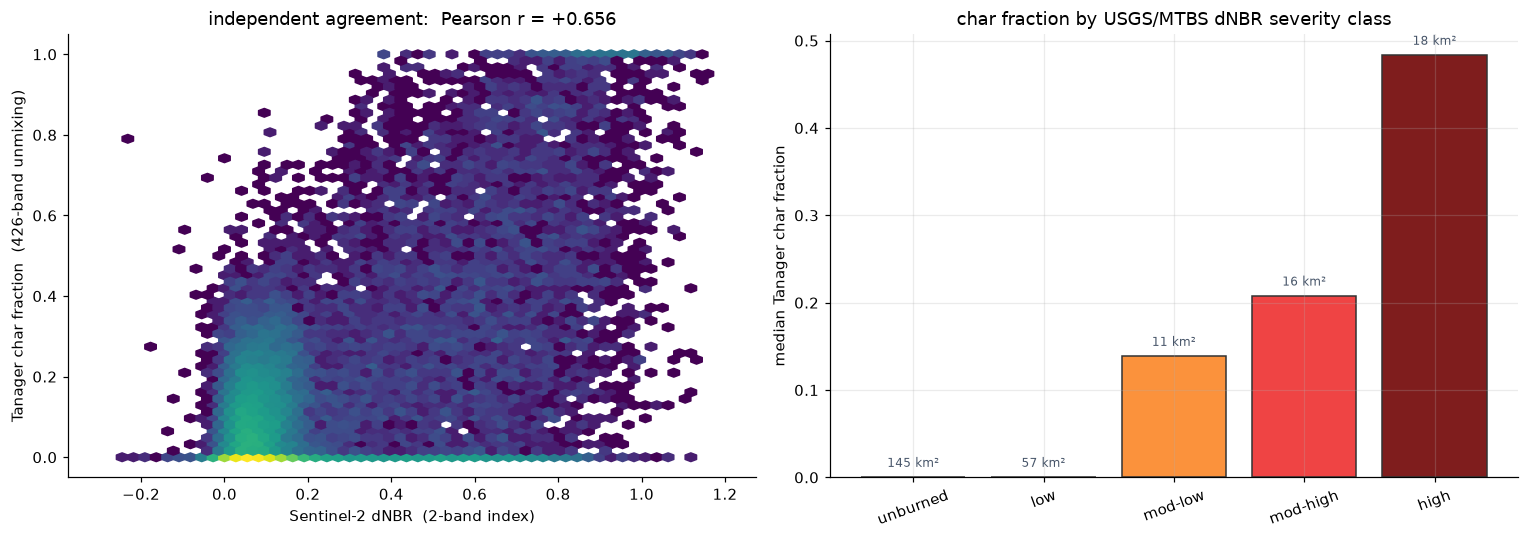

In [11]:
char, dnbr = norm["jan23"][iCH], S2["dnbr_post"]
ok = both & np.isfinite(char) & np.isfinite(dnbr)
r = np.corrcoef(char[ok], dnbr[ok])[0, 1]

CLASSES = [("unburned", -np.inf, 0.10, "#94a3b8"), ("low", 0.10, 0.27, "#fde047"),
           ("mod-low", 0.27, 0.44, "#fb923c"), ("mod-high", 0.44, 0.66, "#ef4444"),
           ("high", 0.66, np.inf, "#7f1d1d")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sub = np.random.default_rng(0).choice(np.flatnonzero(ok.ravel()), 40000, replace=False)
axes[0].hexbin(dnbr.ravel()[sub], char.ravel()[sub], gridsize=55, bins="log",
               cmap="viridis", extent=(-0.3, 1.2, 0, 1))
axes[0].set(xlabel="Sentinel-2 dNBR  (2-band index)",
            ylabel="Tanager char fraction  (426-band unmixing)",
            title=f"independent agreement:  Pearson r = {r:+.3f}")
axes[0].grid(False)

for label, lo, hi, color in CLASSES:
    m = ok & (dnbr >= lo) & (dnbr < hi)
    axes[1].bar(label, np.median(char[m]), color=color, edgecolor="#333")
    axes[1].text(label, np.median(char[m]) + 0.012, f"{m.sum()*900/1e6:.0f} km²",
                 ha="center", fontsize=8, color="#475569")
axes[1].set(ylabel="median Tanager char fraction",
            title="char fraction by USGS/MTBS dNBR severity class")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
print(f"Pearson r = {r:+.3f} between two fully independent measurements.")

**Pearson r = +0.66**, and the median char fraction increases **monotonically** across all
five USGS/MTBS severity classes: 0.000 → 0.000 → 0.146 → 0.194 → 0.488.

Two honest caveats:

- Spearman ρ is lower (+0.35) because FCLS produces many *exact* zeros, so the char
  distribution is zero-inflated and rank correlation is penalised by ties.
- Agreement is only half the story. The hexbin shows char fraction resolving structure
  *within* the high-dNBR class, where dNBR saturates. The 426-band product keeps
  discriminating after the index has stopped.

### The strongest check: an independent spectrometer, the same day

The comparison above uses a Sentinel-2 dNBR **computed in this project** — it tests the
method, but shares an author with the thing it validates. So we went looking for an
externally authored reference. Four candidates failed
(`scripts/external_validation_survey.py` reproduces the search):

| source | usable | why |
|---|---|---|
| MTBS burn severity | **no** | archive stops at 2024; MTBS lags ~18 months |
| USFS BAER soil burn severity 2025 | **no** | mosaic exists, **0 valid pixels** over this AOI |
| NASA JPL S1+S2 severity | **no** | footprint centred on the Eaton fire — 0.9 km² here vs a ~30 km² scar |
| NASA JPL Sentinel-2 dNBR | **no** | its pre-fire scene postdates the Franklin fire |

BAER is empty because these were the wrong kind of fire: Palisades, Franklin and Kenneth
were state-responsibility incidents under California's WERT program, not federal Burned
Area Emergency Response. And the NASA dNBR can't be used because its pre-fire scene is
2 January 2025 — *after* the 10 December Franklin fire — so Franklin reads as **negative**
dNBR. Correct for their purpose, wrong for ours, and a reminder that an authoritative
reference still has to be checked against the fire history.

The fifth candidate worked, and is better than any of them: **NASA/JPL flew AVIRIS-3, an
airborne imaging spectrometer, over these fires on 23 January 2025 — the same day as the
Tanager scene.** Tanager imaged at 18:55 UTC; the flight lines here were acquired
20:13–20:23 UTC, a gap of ~1.4 hours.

That upgrades the validation to **char fraction against char fraction**, with no severity
proxy standing in the middle:

| | Tanager-1 | AVIRIS-3 |
|---|---|---|
| platform | spaceborne | airborne |
| GSD | 30 m | ~3 m |
| bands | 426 (376–2499 nm) | 284 (390–2493 nm) |
| acquired | 23 Jan 18:55 UTC | 23 Jan 20:13–20:23 UTC |

Same endmember library, same FCLS, same 30 m output grid. AVIRIS reflectance is aggregated
to 30 m *before* unmixing, reproducing what Tanager physically does, so the comparison
isolates instrument differences from scale effects. Nothing is downloaded: the 61 lines
qualifying on date and footprint total ~123 GB, so `aviris3.py` streams them via HTTP range
requests and stops once enough lines have been read to cover the scars — four, here.

In [12]:
av = np.load("data/aviris3_char.npz", allow_pickle=True)
aviris = av["char"]
tan = norm["jan23"][iCH]

# This check is January against January, so it uses January validity alone — the `both`
# mask exists for the Jan->Jul comparison and would discard 2,906 pixels for no reason
# here. Same mask as aviris3.py, so the numbers below reproduce the pipeline's own report.
jan_ok = valid["jan23"]
comparable = np.isfinite(aviris) & np.isfinite(tan) & jan_ok
a, t = aviris[comparable], tan[comparable]
r_all = np.corrcoef(a, t)[0, 1]
inside = comparable & any_fire
outside = comparable & ~any_fire

print(f"{len(av['lines'])} same-day AVIRIS-3 flight lines, "
      f"{comparable.sum():,} co-located 30 m pixels ({comparable.sum()*900/1e6:.1f} km2)\n")
print(f"  Pearson r           = {r_all:+.3f}")
print(f"  mean bias (T - A)   = {np.mean(t - a):+.3f}")
print(f"  RMSE                = {np.sqrt(np.mean((t - a)**2)):.3f}")
print(f"  inside perimeters   r = {np.corrcoef(aviris[inside], tan[inside])[0,1]:+.3f}"
      f"   AVIRIS {np.median(aviris[inside]):.3f} vs Tanager {np.median(tan[inside]):.3f}")
print(f"  outside perimeters    AVIRIS {np.median(aviris[outside]):.3f} "
      f"vs Tanager {np.median(tan[outside]):.3f}")

4 same-day AVIRIS-3 flight lines, 56,067 co-located 30 m pixels (50.5 km2)

  Pearson r           = +0.785
  mean bias (T - A)   = -0.060
  RMSE                = 0.202
  inside perimeters   r = +0.702   AVIRIS 0.468 vs Tanager 0.238
  outside perimeters    AVIRIS 0.000 vs Tanager 0.000


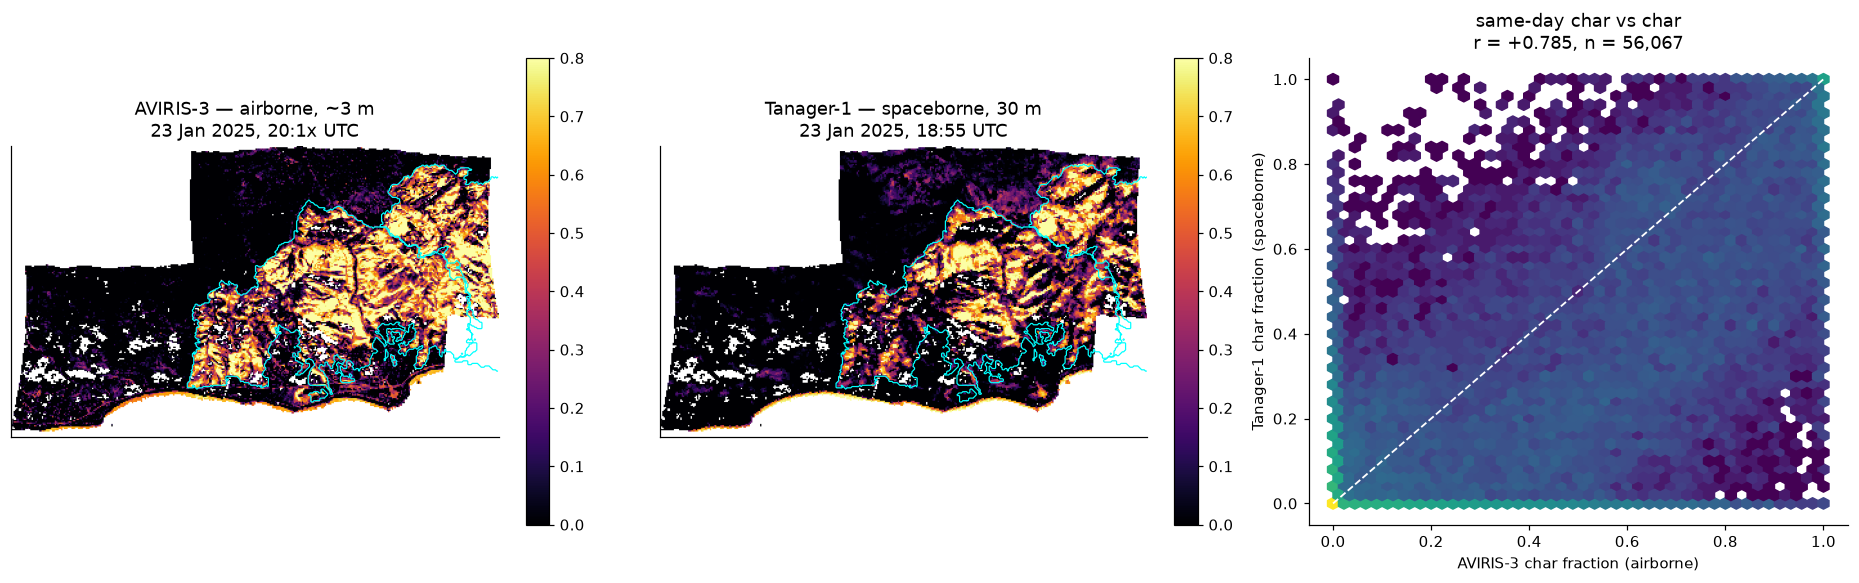

In [13]:
rows, cols = np.where(np.isfinite(aviris))
r0, r1, c0, c1 = rows.min(), rows.max()+1, cols.min(), cols.max()+1
crop = lambda arr: arr[r0:r1, c0:c1]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
for ax, arr, title in [
    (axes[0], crop(np.where(comparable, aviris, np.nan)),
     "AVIRIS-3 — airborne, ~3 m\n23 Jan 2025, 20:1x UTC"),
    (axes[1], crop(np.where(comparable, tan, np.nan)),
     "Tanager-1 — spaceborne, 30 m\n23 Jan 2025, 18:55 UTC"),
]:
    im = ax.imshow(arr, cmap="inferno", vmin=0, vmax=0.8)
    ax.set(title=title, xticks=[], yticks=[]); ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046)
    for m in masks.values():
        ax.contour(crop(m).astype(float), levels=[0.5], colors="cyan", linewidths=0.8)

axes[2].hexbin(a, t, gridsize=45, bins="log", cmap="viridis", extent=(0,1,0,1), mincnt=1)
axes[2].plot([0,1],[0,1],"w--",lw=1.2)
axes[2].set(xlabel="AVIRIS-3 char fraction (airborne)",
            ylabel="Tanager-1 char fraction (spaceborne)",
            title=f"same-day char vs char\nr = {r_all:+.3f}, n = {comparable.sum():,}")
axes[2].grid(False)
plt.tight_layout()

**Two independent imaging spectrometers both return exactly 0.000 char in unburned land.**
The null reported in section 6 rests on Tanager's own unmixing; here it is confirmed by a
different instrument on the same day. The maps are near-identical — scar boundaries and
fine structure inside the perimeters both match.

**But the absolute scale does not validate, and that bounds the claim.** Inside the
perimeters Tanager reads roughly *half* the AVIRIS char fraction (median 0.238 vs 0.468)
despite agreeing strongly on pattern (r = +0.70). The comparison is at matched 30 m
resolution, so this is not a scale artifact.

The likely cause is **endmember purity**. The CHAR endmember is a class *median* over dark
burned Tanager pixels, and that median is itself already a mixture. In linear unmixing the
fraction scale is set by endmember purity: an impure endmember inflates fractions when
applied to data containing purer material, which is what AVIRIS at 3 m provides. Spectral
mixture analysis is known to behave this way; nothing here is broken.

So Tanager char fraction is validated as a **relative** measure: where it says more char,
an independent same-day airborne spectrometer agrees there is more char. Its absolute values
should not be read as literal areal char cover. Every conclusion in this notebook leans only
on the relative measure.

# Part IV — Q3. Does what burned determine what comes back?

This is where our own first answer turned out to be wrong. What follows is the naive
answer, the reason it fails, and what survives two successive controls.

## 6. The naive answer: recovery against a single pooled control

The trap here is seasonality. Between January and July, *unburned* chaparral also loses
greenness, because Southern California goes from wet season to dry season. Without a
control, a burn scar that recovers strongly could still look like "no change". So recovery
is measured **relative to unburned land in the same overlap** (199 km²).

**Read the `vs control` column as provisional.** Pooling every unburned pixel into one
baseline assumes the fires burned the same vegetation the control is made of. They did not,
and the two dominant communities dry down at very different rates, so section 6.2 replaces
this baseline and revises the numbers down.

In [14]:
def med(mask, date, idx):
    v = norm[date][idx][mask]
    return np.median(v[np.isfinite(v)])

rows = [("control (unburned)", control)] + [(f.title(), masks[f] & both) for f in masks]
print(f"{'region':20s} {'km2':>6s} {'char Jan':>9s} {'char Jul':>9s} "
      f"{'GV Jan':>7s} {'GV Jul':>7s} {'dGV':>7s} {'vs control':>11s}")
ctl = None
for label, m in rows:
    cj, cl = med(m, "jan23", iCH), med(m, "jul26", iCH)
    gj, gl = med(m, "jan23", iGV), med(m, "jul26", iGV)
    dg = gl - gj
    if ctl is None:
        ctl = dg
    print(f"{label:20s} {m.sum()*900/1e6:6.1f} {cj:9.3f} {cl:9.3f} "
          f"{gj:7.3f} {gl:7.3f} {dg:+7.3f} {dg-ctl:+11.3f}")

region                  km2  char Jan  char Jul  GV Jan  GV Jul     dGV  vs control
control (unburned)    199.3     0.000     0.000   0.499   0.222  -0.277      +0.000
Palisades              28.8     0.274     0.000   0.000   0.088  +0.088      +0.365
Franklin               16.2     0.180     0.000   0.000   0.209  +0.209      +0.486
Kenneth                 2.8     0.473     0.000   0.000   0.000  +0.000      +0.277


Four things stand out:

- **Char fraction is exactly 0.000 in unburned land, on both dates**, and section 5 showed
  AVIRIS-3 returning the same 0.000 there on the same day. The perimeters located the char
  training pixels, so the null needs the check below before it can be read as a measurement
  rather than a construction.
- **Char is completely gone by July** in every scar — six months and one wet season erase
  the charred-material signal entirely.
- **January char ranks inversely with scar age**: Kenneth (14 days) 0.473 > Palisades
  (16 days) 0.274 > Franklin (44 days) 0.180. Franklin had six extra weeks of weathering.
- **The unburned control *loses* GV (−0.277)** while every scar gains. Without the control,
  Palisades' +0.088 absolute gain would look unimpressive; against control it is +0.365 —
  a number that section 6.2 revises down to **+0.223** once the control is chosen correctly.

**Does the perimeter-based training manufacture that null?** Two measurements say no.
Rebuilding the char endmember with the identical brightness and NDVI rules but *no*
perimeter constraint moves the spectrum by **1.80°** — closer than the 2.8° at which this
project declared two materials inseparable. And char is not gated at the boundary: it rises
over roughly 150–300 m, reaching a 90th percentile of **0.479** just outside the perimeter
line, which a geometrically gated result could not do. The dependency that does bite is the
soil endmember: excluding burned ground from the NPV/soil class moves it **7.53°**, so the
library's soil-versus-char contrast is partly maintained by that exclusion. It cuts the
other way from the headline, though — a char-contaminated soil endmember would absorb
char-like signal and push fractions *down*. `FINDINGS.md` carries the full accounting.

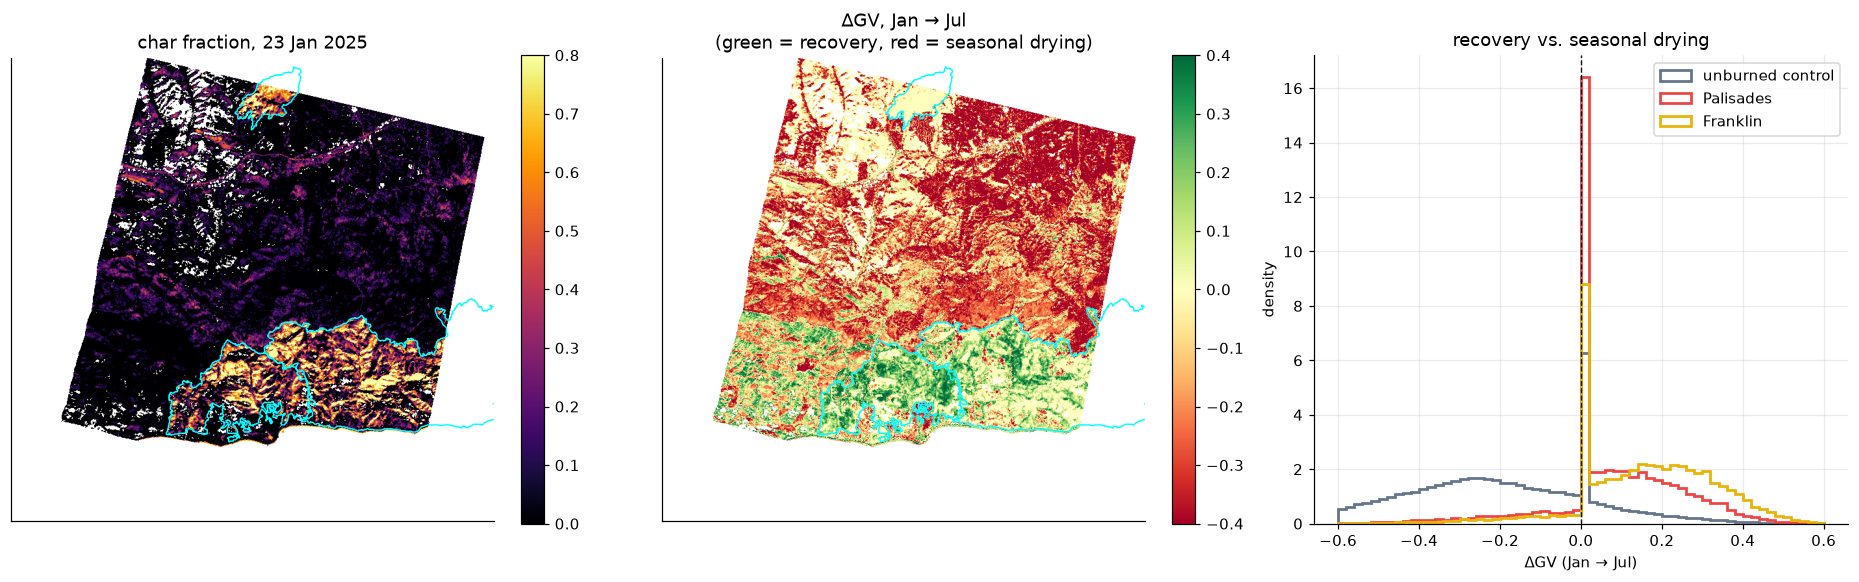

In [15]:
dgv = np.where(both, norm["jul26"][iGV] - norm["jan23"][iGV], np.nan)
char_jan = np.where(both, norm["jan23"][iCH], np.nan)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
im = axes[0].imshow(char_jan, cmap="inferno", vmin=0, vmax=0.8)
axes[0].set_title("char fraction, 23 Jan 2025")
plt.colorbar(im, ax=axes[0], fraction=0.046)

im = axes[1].imshow(dgv, cmap="RdYlGn", vmin=-0.4, vmax=0.4)
axes[1].set_title("ΔGV, Jan → Jul\n(green = recovery, red = seasonal drying)")
plt.colorbar(im, ax=axes[1], fraction=0.046)
for ax in axes[:2]:
    for m in masks.values():
        ax.contour(m.astype(float), levels=[0.5], colors="cyan", linewidths=0.9)
    ax.set(xticks=[], yticks=[]); ax.grid(False)

for label, m, color in [("unburned control", control, "#64748b"),
                        ("Palisades", masks["PALISADES"] & both, "#ef4444"),
                        ("Franklin", masks["Franklin"] & both, "#eab308")]:
    v = dgv[m]
    axes[2].hist(v[np.isfinite(v)], bins=60, range=(-0.6, 0.6), density=True,
                 histtype="step", lw=1.8, color=color, label=label)
axes[2].axvline(0, color="#111", lw=0.9, ls="--")
axes[2].set(xlabel="ΔGV (Jan → Jul)", ylabel="density", title="recovery vs. seasonal drying")
axes[2].legend()
plt.tight_layout()

## 6.1 Why that control is wrong

Here is the assumption failing. LANDFIRE LF2023 Existing Vegetation Type, exported **onto
the Tanager grid itself** (713 × 743 at 30 m, same origin, nearest-neighbour, no
resampling), shows the two large fires burned close to opposite communities.

In [16]:
from vegtype import CHAPARRAL, COASTAL_SCRUB, NATURAL

comp = RBT["burned_composition"]
print("Burned area by pre-fire vegetation type (km2):")
print(f"{'fire':12s}{'Dry-Mesic Chaparral':>22s}{'Coastal Scrub':>16s}")
for fire, row in comp.items():
    print(f"{fire:12s}{row['Dry-Mesic Chaparral']:22.1f}{row['Coastal Scrub']:16.1f}")

print("\nUnburned control, by vegetation type (the seasonal baseline):")
for name, c in RBT["controls"].items():
    print(f"  {name:28s} n={c['n_px']:6d}   dGV = {c['dgv']:+.3f}")
print(f"  {'POOLED (used in 6)':28s} n={RBT['controls_pooled']['n_px']:6d}"
      f"   dGV = {RBT['controls_pooled']['dgv']:+.3f}")

Burned area by pre-fire vegetation type (km2):
fire           Dry-Mesic Chaparral   Coastal Scrub
PALISADES                     13.4             3.1
Franklin                       3.5             6.7
KENNETH                        0.1             0.9

Unburned control, by vegetation type (the seasonal baseline):
  Dry-Mesic Chaparral          n= 60112   dGV = -0.164
  Coastal Scrub                n= 36012   dGV = -0.066
  Coast Live Oak Woodland      n= 12540   dGV = -0.262
  Mesic Chaparral              n= 10626   dGV = -0.255
  Mixed Evergreen Woodland     n=  7417   dGV = -0.252
  Native Grassland             n=  5100   dGV = +0.000
  Ruderal Grassland (exotic)   n=  7098   dGV = +0.000
  Ruderal Scrub (exotic)       n=  3748   dGV = -0.057
  POOLED (used in 6)           n=251906   dGV = -0.162


Palisades is **chaparral-dominated**, Franklin is **coastal-scrub-dominated** — and unburned
chaparral loses **−0.164** GV over these six months while unburned coastal scrub loses only
**−0.066**. The pooled control (−0.162) is essentially the chaparral control, because
chaparral dominates the unburned area. Applying it to Franklin subtracted a baseline about
0.10 too negative and **inflated Franklin's apparent recovery**.

## 6.2 Control 1 — compare like with like

Every burned stratum is now compared against unburned pixels of the **same** vegetation
class, inside the same overlap.

In [17]:
rows = [s for s in RBT["strata"] if s["evt_code"] in (CHAPARRAL, COASTAL_SCRUB)]
print(f"{'fire':11s}{'vegetation type':24s}{'km2':>7}{'dGV':>9}{'vs same-type':>14}{'charJan':>9}")
for s in rows:
    print(f"{s['fire']:11s}{s['evt_name']:24s}{s['km2']:7.1f}{s['dgv']:+9.3f}"
          f"{s['dgv_vs_control']:+14.3f}{s['char_jan']:9.3f}")

flagged = [s for s in RBT["strata"] if not s["shade_reliable"]]
print(f"\n{len(flagged)} strata fail the shade check and are excluded from all claims:")
for s in flagged:
    print(f"  {s['fire']:11s}{s['evt_name']:26s} shade p90 = {s['shade_p90']:.2f}")

fire       vegetation type             km2      dGV  vs same-type  charJan
PALISADES  Dry-Mesic Chaparral        13.4   +0.059        +0.223    0.286
PALISADES  Coastal Scrub               3.1   +0.026        +0.092    0.105
Franklin   Dry-Mesic Chaparral         3.5   +0.218        +0.382    0.180
Franklin   Coastal Scrub               6.7   +0.144        +0.210    0.081
KENNETH    Coastal Scrub               0.9   +0.000        +0.066    0.471

4 strata fail the shade check and are excluded from all claims:
  PALISADES  Coast Live Oak Woodland    shade p90 = 0.58
  PALISADES  Mixed Evergreen Woodland   shade p90 = 0.58
  Franklin   Coast Live Oak Woodland    shade p90 = 0.65
  Franklin   Mixed Evergreen Woodland   shade p90 = 0.65


**The conclusion survives the correction.** Franklin still recovers more than Palisades
*within each vegetation type separately*: +0.382 vs +0.223 in chaparral, +0.210 vs +0.092 in
coastal scrub. "Recovery ranks with time since fire" now holds with what was growing there
held constant. The magnitude drops, Franklin's +0.486 against the pooled control becoming
**+0.382**, and that drop is the inflation the wrong baseline was hiding.

Two results fall out for free:

- **Chaparral out-recovers coastal scrub against its own control**, in both fires — consistent
  with resprouter dominance and release from competition after canopy removal.
- **January char tracks fuel type**: 0.286 in chaparral vs 0.105 in coastal scrub within
  Palisades. Heavier fuel leaves more char — an independent check that the char endmember
  behaves physically.

**A limit, enforced in code.** Shade normalization divides by (1 − f_shade) and is only
stable where the shade fraction is small. At 34° sun in January that holds for chaparral and
coastal scrub (median shade 0.000) but not for canyon woodland, where p90 shade reaches 0.65.
Those strata carry a genuinely high *raw* char fraction, but normalization inflates it, so
every stratum records `shade_reliable` and the flagged ones are excluded above. Open water
is the limiting case: a correctly near-zero raw char of 0.053 becomes **0.856** once
normalized, because the ocean is almost pure shade.

## 6.3 Control 2 — was it the vegetation, or just how hard it burned?

Vegetation type and burn severity are tangled: chaparral both burned hotter *and* recovered
differently. So neither effect above can be pinned on vegetation until it survives inside a
**fixed severity band**. Severity here is Tanager's own January char fraction, and comparing
within a band also cancels any January floor effect, since both sides start from the same
place.

In [18]:
sev = RBT["severity_control"]
print("Does the VEGETATION effect survive at fixed severity?  (dGV vs same-type control)")
print(f"{'char bin':>14}{'chaparral':>12}{'coastal scrub':>15}{'difference':>12}")
for r in sev["veg_effect"]:
    print(f"  [{r['char_lo']:.2f},{r['char_hi']:.2f}){r['chaparral']:12.3f}"
          f"{r['coastal_scrub']:15.3f}{r['difference']:12.3f}")

print("\nDoes the FIRE-AGE effect survive at fixed severity?  (chaparral only)")
print(f"{'char bin':>14}{'Palisades':>12}{'Franklin':>12}{'difference':>12}")
for r in sev["age_effect"]:
    print(f"  [{r['char_lo']:.2f},{r['char_hi']:.2f}){r['PALISADES']:12.3f}"
          f"{r['Franklin']:12.3f}{r['difference']:12.3f}")

Does the VEGETATION effect survive at fixed severity?  (dGV vs same-type control)
      char bin   chaparral  coastal scrub  difference
  [0.00,0.05)       0.137          0.052       0.085
  [0.05,0.15)       0.188          0.151       0.037
  [0.15,0.30)       0.237          0.176       0.061
  [0.30,0.50)       0.273          0.198       0.075
  [0.50,1.01)       0.320          0.231       0.089

Does the FIRE-AGE effect survive at fixed severity?  (chaparral only)
      char bin   Palisades    Franklin  difference
  [0.00,0.05)       0.137       0.283       0.146
  [0.05,0.15)       0.150       0.335       0.185
  [0.15,0.30)       0.195       0.376       0.181
  [0.30,0.50)       0.242       0.402       0.160
  [0.50,1.01)       0.305       0.446       0.141


**Both effects survive at every severity level.** Chaparral out-recovers coastal scrub in all
five char bins (+0.037 to +0.089), and Franklin out-recovers Palisades in all five
(+0.141 to +0.185) — a difference that is, if anything, *more* stable across severity than
the headline numbers suggest. Neither result is an artifact of one fire having burned harder
than the other.

A secondary observation, reported with its caveat: absolute July greenness **rises** with
January severity in burned chaparral (GV 0.000 → 0.196 across the char bins). The usual floor
effect cannot explain it, since January GV is 0.000 in *every* bin — the trend lives entirely
in the July state. It fits with more complete canopy removal producing more vigorous
resprouting, and with high-severity sites having carried more fuel because they were more
productive to begin with. But FCLS is zero-inflated, so the low bins sit on a floor of
exact zeros; `gv_jul_zero_frac` in the JSON records how much of each bin that is.

## 6.4 The context that reframes all of it: this is a reburn landscape

CAL FIRE FRAP historic perimeters (1980–2023), rasterized to a per-pixel prior-fire count on
the same grid. **81.7 % of the area that burned in 2024-25 had already burned at least once
since 1980, and 32.8 % three or more times.**

In [19]:
conv = RBT["type_conversion"]
print("Land that did NOT burn in 2024-25, by how often it burned 1980-2023:")
print(f"{'prior fires':>12}{'n px':>9}{'chaparral':>12}{'coastal scrub':>15}{'exotic':>9}")
for r in conv:
    print(f"{r['prior_fires']:12d}{r['n_px']:9d}{r['chaparral']:11.1%}"
          f"{r['coastal_scrub']:15.1%}{r['exotic']:9.1%}")

Land that did NOT burn in 2024-25, by how often it burned 1980-2023:
 prior fires     n px   chaparral  coastal scrub   exotic
           0   101157       9.7%           4.1%     1.0%
           1    59678      35.2%           8.9%     2.3%
           2    49078      40.5%          21.9%     8.5%
           3    27497      25.7%          28.5%    11.4%
           4    13719      17.0%          54.6%     8.0%
           5      749       6.3%          57.9%    10.9%


Chaparral gives way to coastal sage scrub, and both give way to exotics, as fire frequency
rises — the documented **type-conversion** sequence, recovered here from two independent
public datasets, neither built for this purpose. (Read the trend across rows 1–5; the
0-prior-fire row is dominated by developed and water pixels.)

Every recovery number above should be read against this. Fastest is not best: within burned
chaparral, ΔGV rises monotonically with prior-fire count (+0.059 at one prior fire to +0.220
at four), while July NPV falls from 0.926 to 0.769. Repeatedly burned sites are largely
type-converted already, so what greens up there is herbaceous cover where shrubs used to be.

# Part V — What we tested and rejected

Five claims were killed by measurement during this project. They are listed here because
each one changed the method, and because a result that survives this list is worth more than
one that was never exposed to it. The first four are shown where they happened, in sections
1, 3 and 5; this is the ledger.

| claim tested | verdict | what it changed |
|---|---|---|
| pre-fire / post-fire dNBR framing (§1) | every fire predates the January scene | recovery series, not a before/after |
| a white-ash endmember (§3) | 2.8° from bright burn, which is 5.4° from char — not separable | four-member library, not five |
| blind VCA, then region-constrained VCA (§3) | vertices are ocean and shadow; assumed SWIR2 shoulders were wrong | measure separability instead of assuming a library |
| four external severity products (§5) | MTBS ends 2024; BAER empty (state WERT fires); NASA S1+S2 is on Eaton; NASA dNBR's "pre" postdates Franklin | validate against same-day AVIRIS-3 instead |

The fourth row is worth one extra sentence: NASA's Sentinel-2 dNBR uses a 2 January 2025
pre-fire scene, *after* the 10 December Franklin fire, so Franklin reads as **negative**
dNBR — correct for their purpose, wrong for ours, and a reminder to check a reference
against the fire history before trusting it.

**The fifth rejection was one of our own results, and it needs the space.** We expected to
show that a 2-band greenness index reaches the *opposite* conclusion about recovery, and
tested it by computing NDVI from Tanager's own bands, on the same instrument, the same
pixels and the same dates. It does not hold. ΔNDVI and ΔGV do rank the burn-history gradient in opposite
directions (r = 0.54), but ΔNDVI wanders off monotonic, and both are difference measures
sharing a January baseline that reburned sites inflate with wet-season grass. The decisive
test — whether, at a *fixed* NDVI, the unmixing reveals composition the index cannot see —
came out null: at a given July NDVI, burn history barely moves GV (0.036 vs 0.060; 0.159 vs
0.195). The low-NDVI comparison is contaminated by FCLS zero-inflation too (69 % exact zeros
in the 0.15–0.25 bin). A defensible version needs same-date burned-vs-unburned strata and
explicit handling of the zero floor. That is a research project of its own, and we make no
claim about it here.

# Part VI — What the hyperspectral data bought

**Q1 — measuring material, not contrast.** The char endmember returns **exactly 0.000 in
unburned land on both dates**, and nothing geometric enforces that null: the per-pixel
unmixing carries no spatial information at all, and char does activate outside the perimeters
wherever dark burn-like material exists. It ranks inversely with scar age (Kenneth 0.473 at
14 days > Palisades 0.274 at 16 > Franklin 0.180 at 44), it tracks fuel type (0.286 chaparral
vs 0.105 coastal scrub), and it keeps resolving structure *inside* the high-dNBR class where
the index saturates. The library ended up with four members because a 426-band separability
test established that no white-ash endmember exists here.

**Q2 — the fraction is trustworthy as a relative measure, and only that.** Against same-day
airborne AVIRIS-3: **r = +0.785** over 56,067 co-located 30 m pixels, and **both instruments
independently return 0.000 char in unburned land**. Against an independent Sentinel-2 dNBR:
r = +0.656, monotonic across all five USGS severity classes. Inside the perimeters, though,
Tanager reads about *half* the airborne fraction, most likely from endmember purity — so char
is validated as a relative measure, and 0.30 does not mean 30 % areal cover. Every conclusion
here leans only on the relative measure.

**Q3 — what burned does determine what comes back, and our first answer was wrong.** The two
large fires burned near-opposite vegetation, making the pooled control invalid. With a
per-vegetation-type control the age ranking survives at corrected magnitude (Franklin +0.382
vs Palisades +0.223 in chaparral), and it survives again inside every fixed severity band
(+0.141 to +0.185). Meanwhile 81.7 % of this landscape had burned before, and the sites
greening fastest are the ones furthest along a chaparral → coastal sage scrub → exotic grassland
conversion.

| result | why it needed hyperspectral |
|---|---|
| char fraction **0.000** in unburned land | a material endmember either activates or it does not — an index has no such null |
| char ranks inversely with scar age | measures *charred material abundance*, not a brightness contrast |
| **no separable white ash** | a negative result only a 426-band separability test can establish |
| Jan (34° sun) vs Jul (73° sun) comparable at all | a shade endmember absorbs the illumination term; a band ratio cannot |
| severity used as a *control variable* | char fraction is our own measurement, not an external product |

**Where Tanager is and is not load-bearing.** LANDFIRE supplies the vegetation strata and
CAL FIRE the burn history — but every *measured* quantity in Part IV is Tanager's: the
fractions, the char severity used as a control, and the composition of the recovery. Most of
all, there is no pre-fire Tanager scene, so the only reason a 34°-sun January image is
comparable to a 73°-sun July image is the photometric shade endmember, justified by the
measured flat gain of 1.050 across usable bands (1.049 for the all-good-bands regression in
`FINDINGS.md`). A broadband index across those two dates would mostly be tracking
topographic shadow.

**Reproducibility.** Every figure derives from the `scripts/` pipeline, from public data
requiring no authentication: Planet's Open STAC catalog (CC-BY-4.0), NIFC/WFIGS perimeters
(public domain), Copernicus Sentinel-2 L2A via AWS Earth Search, LANDFIRE (USGS) and CAL FIRE
FRAP. AVIRIS-3 requires a free NASA Earthdata login.

**Limitations, stated plainly.** The January scene carries a `test` quality flag — shown to be
spectrally sound, but not an operational product. The endmember library is January-derived,
which raises July RMSE (0.038 vs 0.017). Fire perimeters are not burn masks, so perimeter-based
skill scores understate true performance. With two dates we resolve a trajectory's endpoints,
not its shape. LANDFIRE EVT is a *modeled* product and is the stratifier for every number in
Part IV; the NPS Santa Monica Mountains alliance map would be the independent check, and no
live service for it was found. Species-level composition is not resolvable at 30 m in
chaparral, where the vegetation grain is finer than the pixel — the honest next step is
AVIRIS-3 at 3 m. And recovery is measured at a single six-month interval; whether the ranking
holds through the second wet season is not answerable from this pair.